# Panel 4H

Split from `ahmm_final_figures.ipynb`. Covers across-session left-bar tuning heatmap and PC loadings.


In [1]:
import pickle
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ahmm_eval import (
    build_cat_ids_from_obs_labels,
    build_conditioned_obs_heatmap,
    build_similarity_matrix,
    build_within_session_pv_cov_df_best_models,
    collect_left_tuning_all_sessions_from_df,
    collect_pv_lag_curves_for_best_models,
    compute_state_tuning_all_obs,
    load_best_pde_model_for_session,
    load_within_session_model_for_session,
    model_action_distribution_all_sessions,
    obs_heatmap_corr_for_session_and_model,
    prepare_obs_heatmap_crosscorr_2x2,
    sample_ahmm,
    save_pv_df_to_mat,
    select_left_bar_tuning,
    prep_dfv_for_heatmap,
        repair_model_paths,
    resolve_data_path,
)
from ahmm_plotting import (
    build_obs_raster_sorted,
    make_obs_colors,
    parula,
    plot_conditioned_obs_heatmap,
    plot_confusion_heatmap,
    plot_heatmap_and_pc_loadings,
    plot_metric_heatmap,
    plot_model_action_heatmap,
    plot_obj1_tuning_heatmap,
    plot_obs_raster_sorted,
    plot_pv_df_violin_sanity,
    plot_pv_lag_mean_sem,
    plot_tuning_heatmap,
    show_pv_representation_ahmm_dataset,
)
from ahmm_utils import (
    SingleTrackConfig,
    SingleTrackGenerator,
    Vocab,
    build_vocab,
    load_ahmm,
    make_session_lookup,
    records_to_dataset,
    train_test_split_random,
)




In [2]:
sessions_combined = pd.read_pickle(resolve_data_path('sessions_combined.pkl', data_roots=('data','demo_data','.')))



In [3]:
heights_in_data = sorted({
    int(h) for sess in sessions_combined for (h, _, _) in sess["records"]
} | {
    int(h) for sess in sessions_combined for (_, h, _) in sess["records"]
})
heights = heights_in_data  # or overwrite with your canonical list if you prefer

vocab: Vocab = build_vocab(heights, height_encoding='split')

# Your deterministic task config (you can change these to experiment)
cfg = SingleTrackConfig(
    tower_heights=heights,
    height_encoding='split',
    p_gap=1.0,
    p_reward_given_correct=1.0,
    p_reward_given_incorrect=0.0
)
gen = SingleTrackGenerator(vocab, cfg)

action_labels = [vocab.id_to_action[i] for i in range(len(vocab.id_to_action))]
obs_labels    = [k for k,_ in sorted(vocab.obs_to_id.items(), key=lambda kv: kv[1])]
obs_colors    = make_obs_colors(obs_labels)
sess_by_key = make_session_lookup(sessions_combined)




In [4]:
dfv_rand_25 = repair_model_paths(pd.read_pickle(resolve_data_path("dfv_rand_25.pkl", data_roots=("data","demo_data","."))))



In [5]:
df_25_rand = repair_model_paths(pd.read_pickle(resolve_data_path("df_25_rand.pkl", data_roots=("data","demo_data","."))))



In [7]:
cg_df_rand_25 = repair_model_paths(pd.read_pickle(resolve_data_path("rand_train_val_cg_rank1_pde_behavior_cross_compare_results_25_states.pkl", data_roots=("data","demo_data","."))))



### Figure 4H

In [8]:
tuning_all, left_labels, meta_df = collect_left_tuning_all_sessions_from_df(
    sessions_combined, gen, vocab,
    dfv=dfv_rand_25,
    df_models=df_25_rand,
    groups=("AA","BA"),
    stream=False,
    use_best=True
)




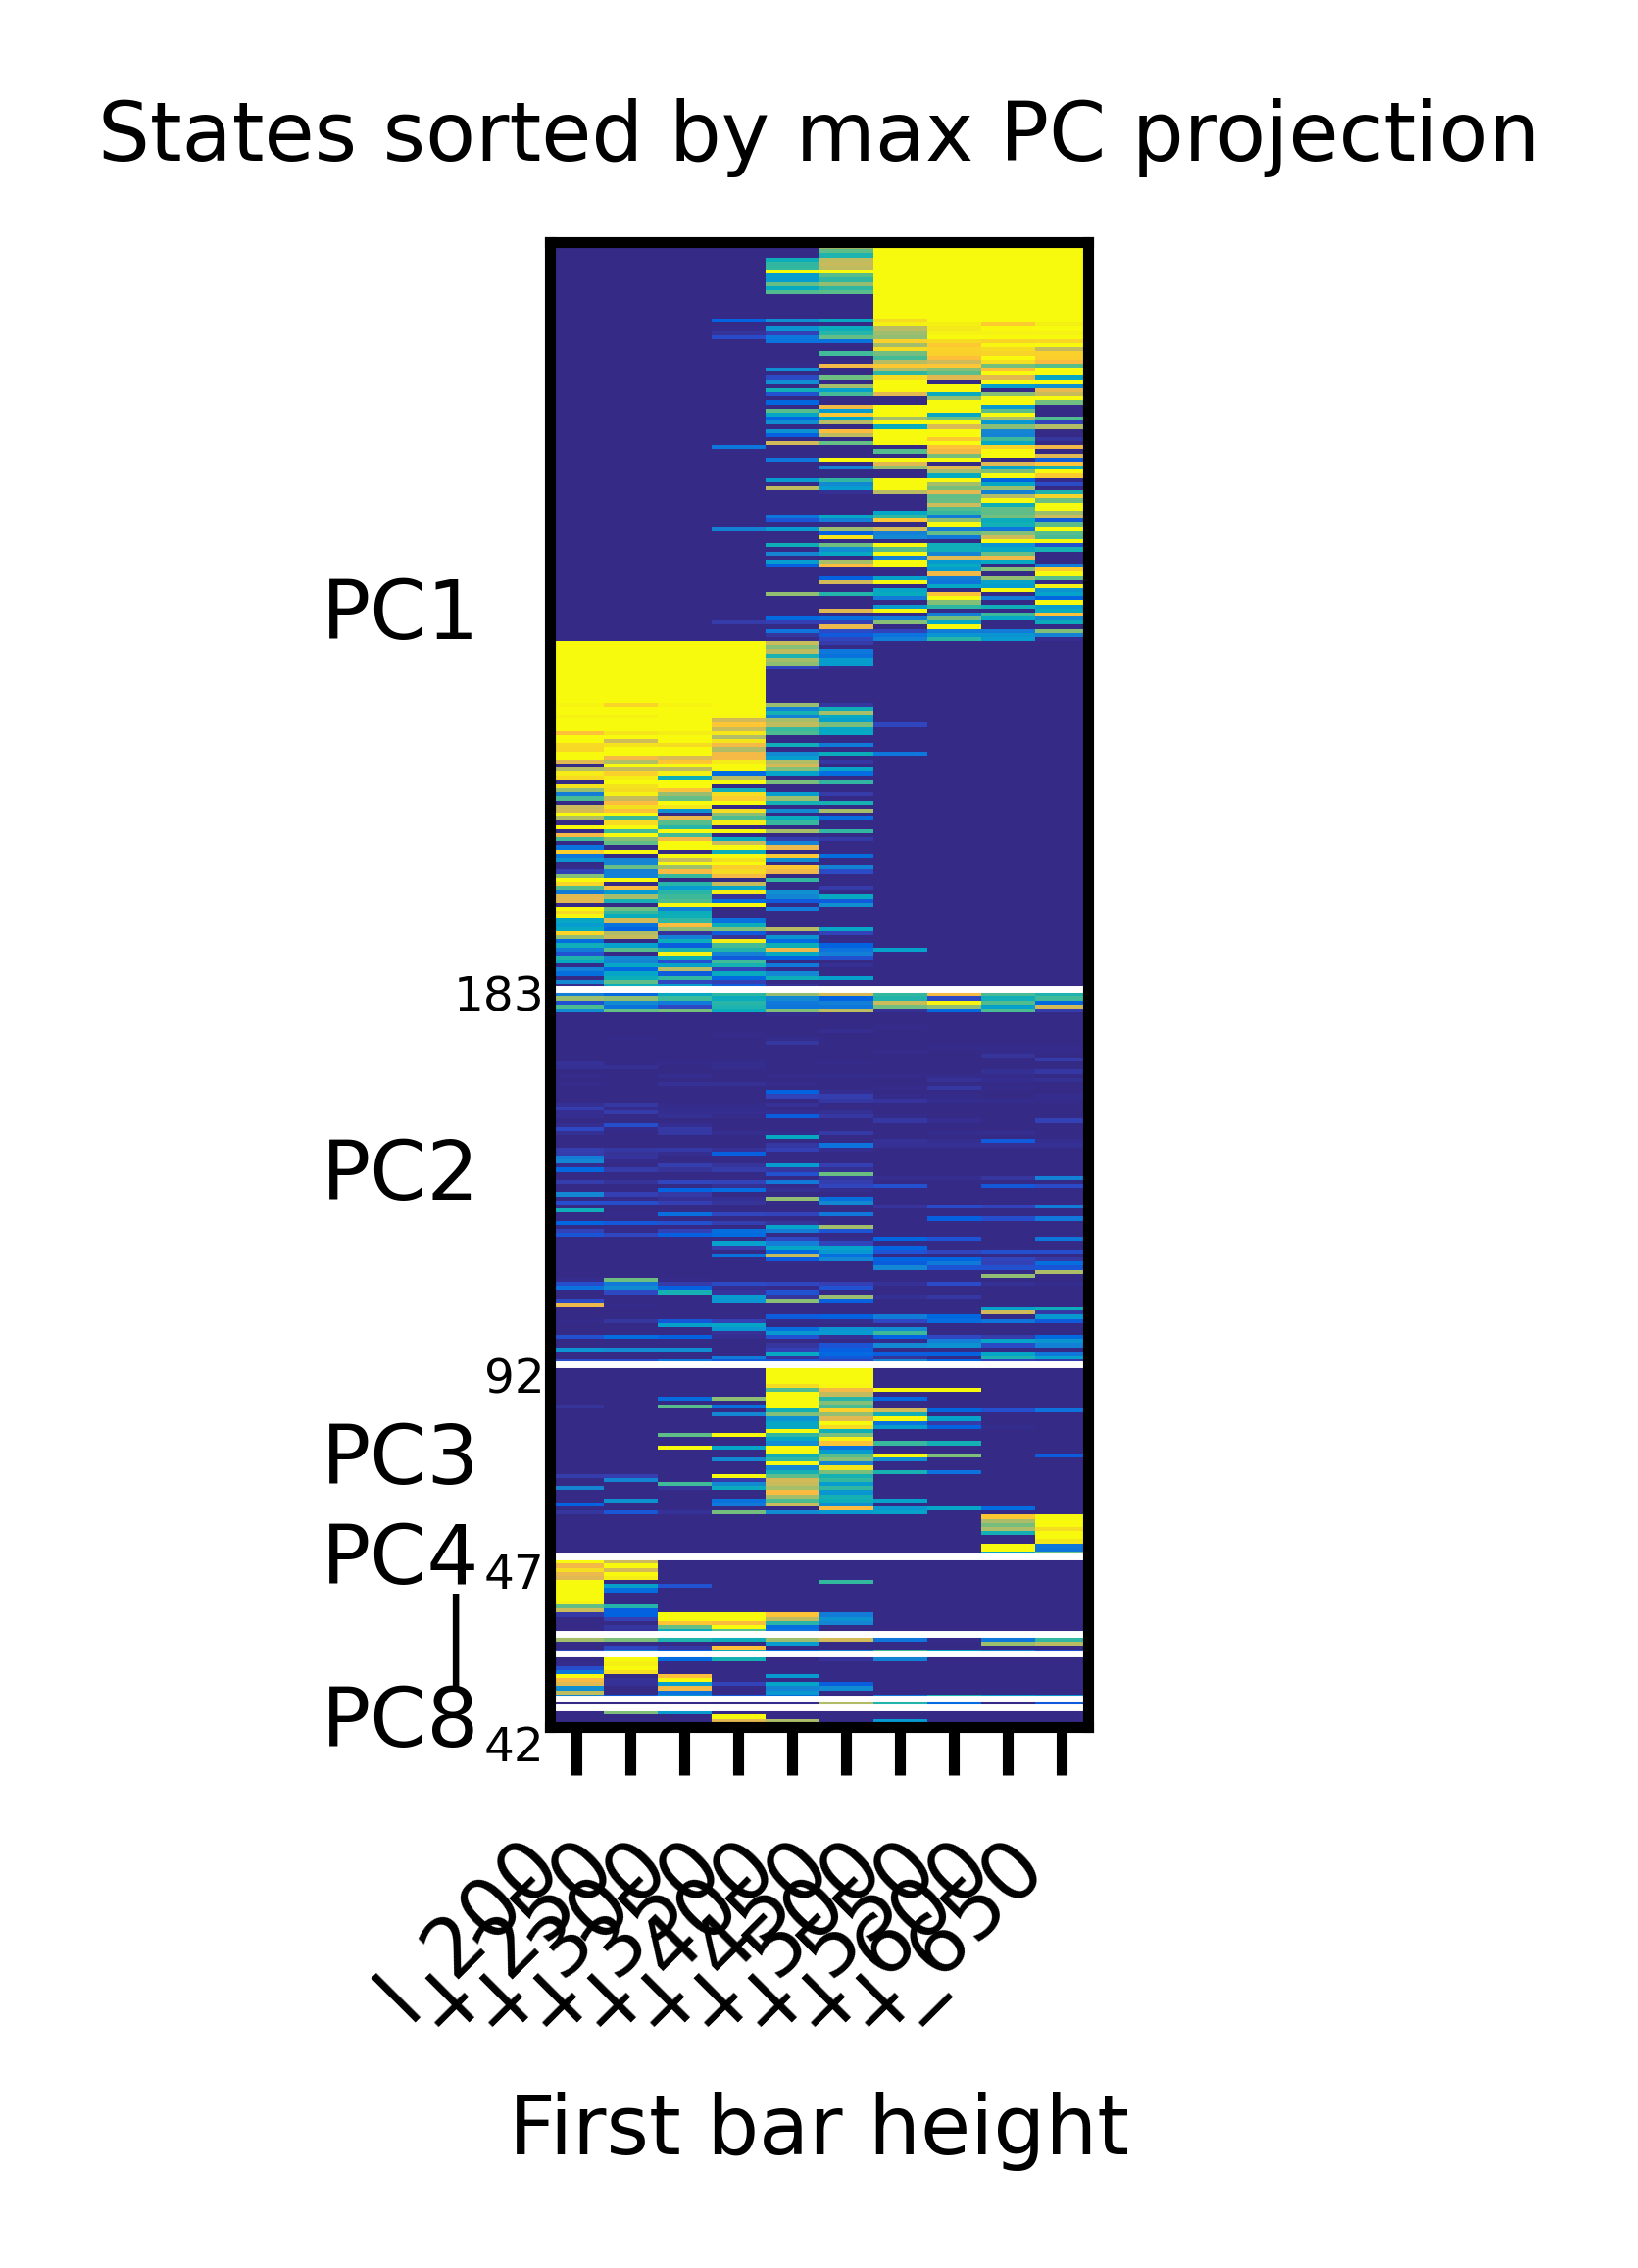

In [9]:
fig = plot_heatmap_and_pc_loadings(
    tuning_all,
    left_labels,
    figsize_cm=(1.8, 5),
    dpi=1000,
    cmap=parula,
    fontsize=dict(
        title=6,
        axis_label=6,
        tick=6,
        pc_label=6,
        pc_count=3.5,
    ),
    pc_marker_size=2.5,        # ← much cleaner
    pc_linewidth=0.5,
    pc_marker_edgewidth=0.5,
    seg_line_color="white",
    seg_line_width=0.5,
    show_pc_loadings=False,
    pc_label_x=-1.8,
    pc_groups=[(1,1), (2,2), (3,3), (4,8)],   # 1-indexed PCs
    pc_group_dash="│",
    
)


